# 확률분포

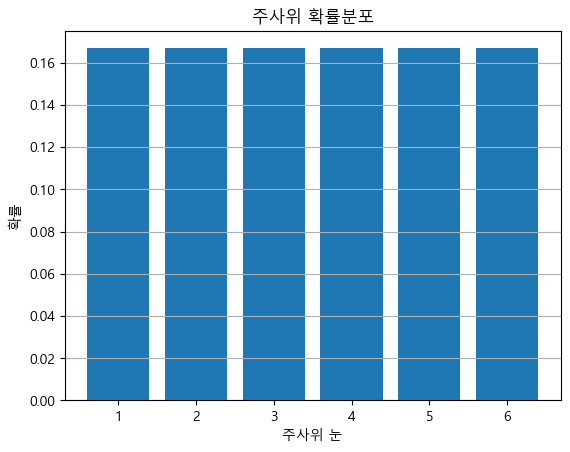

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ✅ 한글 폰트 설정 (Windows: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 주사위 눈 (1~6)
x = np.arange(1, 7)
# 공정한 주사위의 확률분포: 모두 1/6
probs = [1/6] * 6  #6을 곱하는 이유는  6번 반복해서 리스트로 만든다는 의미 - 각 눈별로 확률이 동일하므로 모두 1/6로 설정

# 시각화
plt.bar(x, probs)
plt.xticks(x)
plt.xlabel("주사위 눈")
plt.ylabel("확률")
plt.title("주사위 확률분포")
plt.grid(axis='y')
plt.show()

In [26]:
import pandas as pd
# 기대값
data ={
    '상금': [0,100,1000],  # x
    '확률': [0.5, 0.3, 0.2]  # f(x)
}
df =pd.DataFrame(data)
df['exp_value'] = df['상금'] * df['확률']
print(f'복권의 기대값: {df['exp_value'].sum()}원')

복권의 기대값: 230.0원


In [27]:
# 베르누이 분포 예시 - 동전 던지기
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

# 베르누이 분포 파라미터 설정
p = 0.5  # 앞면이 나올 확률

# 베르누이 확률변수 생성
X = bernoulli(p)
print(X)

In [28]:
# 1회 시행 결과 시뮬레이션 (0: 뒷면, 1: 앞면)
result = X.rvs(size=1)
print(f"동전 1회 던지기 결과: {'앞면' if result[0] == 1 else '뒷면'}")

동전 1회 던지기 결과: 뒷면


In [29]:
# 여러 번 시행 결과 시뮬레이션
n_trials = 1000
results = X.rvs(size=n_trials)
success_count = np.sum(results)
success_count  # 앞면인 횟수 - 성공

np.int64(504)

In [30]:
# 결과 분석
success_count = np.sum(results)
success_rate = success_count / n_trials
success_rate

np.float64(0.504)

1000번 던졌을 때 앞면 나온 횟수: 504
앞면 나올 확률 (이론값: 0.5, 실험값: 0.5040)


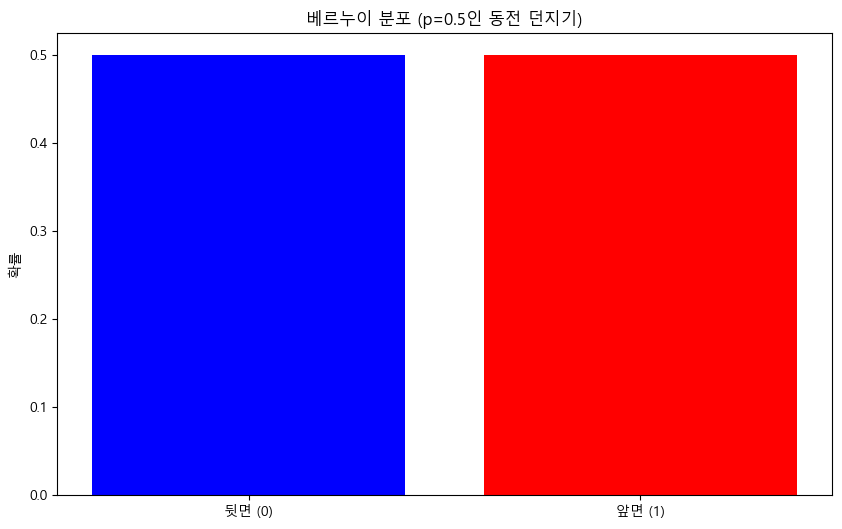

In [31]:
print(f"1000번 던졌을 때 앞면 나온 횟수: {success_count}")
print(f"앞면 나올 확률 (이론값: {p}, 실험값: {success_rate:.4f})")

# 시각화ㄴ
plt.figure(figsize=(10, 6))
plt.bar([0, 1], [1-p, p], color=['blue', 'red'])
plt.xticks([0, 1], ['뒷면 (0)', '앞면 (1)'])
plt.ylabel('확률')
plt.title('베르누이 분포 (p=0.5인 동전 던지기)')
plt.show()


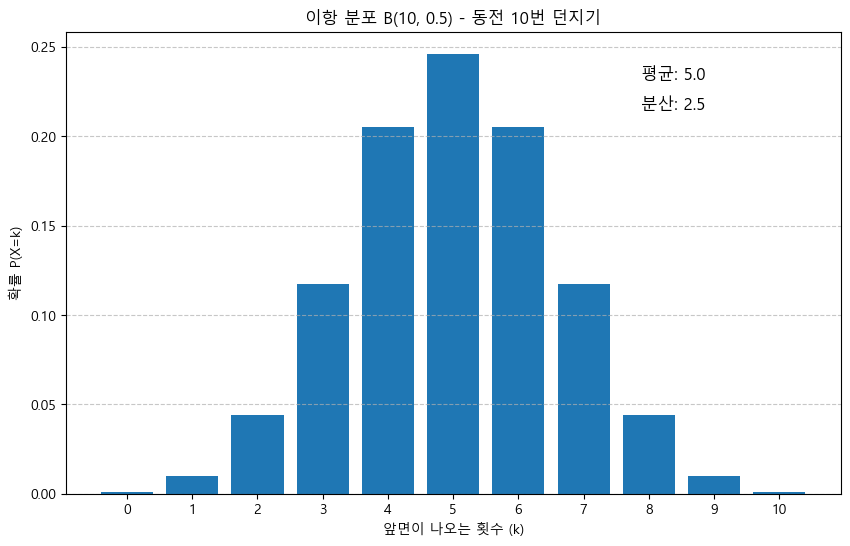

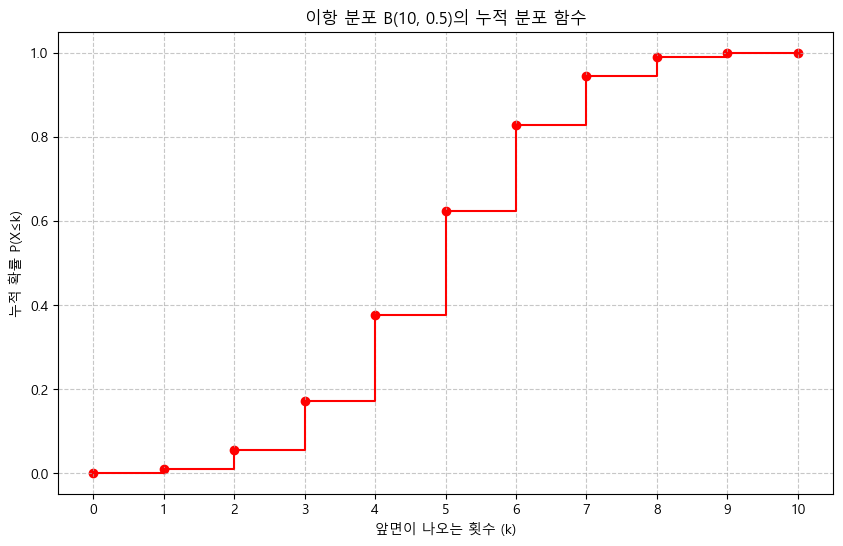

In [32]:
# 동전을 10번 던져서 앞면이 5번 나올 확률 계산
# 이항 분포 예시 - 동전 10번 던지기
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# 이항 분포 파라미터 설정
n = 10  # 시행 횟수
p = 0.5  # 성공 확률(동전 앞면이 나올 확률)

# 이항 확률변수 생성
X = binom(n, p)

# 가능한 모든 결과값(0부터 n까지)
k_values = np.arange(0, n+1)

# 각 결과값의 확률 계산
pmf_values = X.pmf(k_values)

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.bar(k_values, pmf_values)
plt.xlabel('앞면이 나오는 횟수 (k)')
plt.ylabel('확률 P(X=k)')
plt.title(f'이항 분포 B({n}, {p}) - 동전 10번 던지기')
plt.xticks(k_values)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 평균과 분산 출력
mean = n * p
var = n * p * (1-p)
plt.figtext(0.7, 0.8, f'평균: {mean}', fontsize=12)
plt.figtext(0.7, 0.75, f'분산: {var}', fontsize=12)

plt.show()

# 누적 분포 함수(CDF) 계산 및 시각화
cdf_values = X.cdf(k_values)

plt.figure(figsize=(10, 6))
plt.step(k_values, cdf_values, where='post', color='red')
plt.scatter(k_values, cdf_values, color='red')
plt.xlabel('앞면이 나오는 횟수 (k)')
plt.ylabel('누적 확률 P(X≤k)')
plt.title(f'이항 분포 B({n}, {p})의 누적 분포 함수')
plt.xticks(k_values)
plt.grid(linestyle='--', alpha=0.7)
plt.show()


# 이항 분포를 적용할 수 있는 사례

1. 시험 합격률이 70%, 100명, 80명 이상 합격일 확률
2. 불량률 5%, 20개 샘플, 불량제품이 2개 이하일 확률

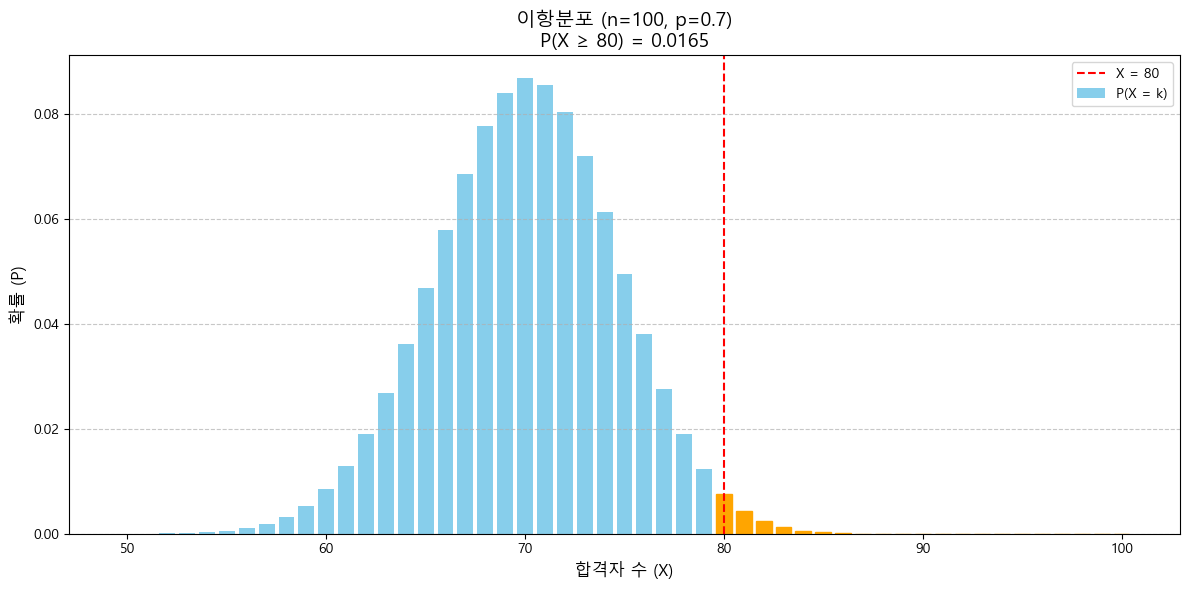

In [ ]:
# 1. 시험 합격률이 70%, 100명, 80명 이상 합격일 확률
# import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# 이항분포 파라미터
n = 100          # 시행 횟수 (총 응시자 수)
p = 0.7          # 성공 확률 (합격 확률)
x = np.arange(50, n + 1)  # X축 범위: 50 ~ 100

# 확률 질량 함수 (PMF)
pmf = binom.pmf(x, n, p)

# 시각화
plt.figure(figsize=(12, 6))
bars = plt.bar(x, pmf, color='skyblue', label='P(X = k)')

# 80명 이상인 부분만 강조
for i, val in enumerate(x):
    if val >= 80:
        bars[i].set_color('orange')

# 확률 계산 및 표시
prob = 1 - binom.cdf(79, n, p)
plt.title(f'이항분포 (n=100, p=0.7)\nP(X ≥ 80) = {prob:.4f}', fontsize=14)
plt.xlabel('합격자 수 (X)', fontsize=12)
plt.ylabel('확률 (P)', fontsize=12)
plt.axvline(80, color='red', linestyle='--', label='X = 80')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


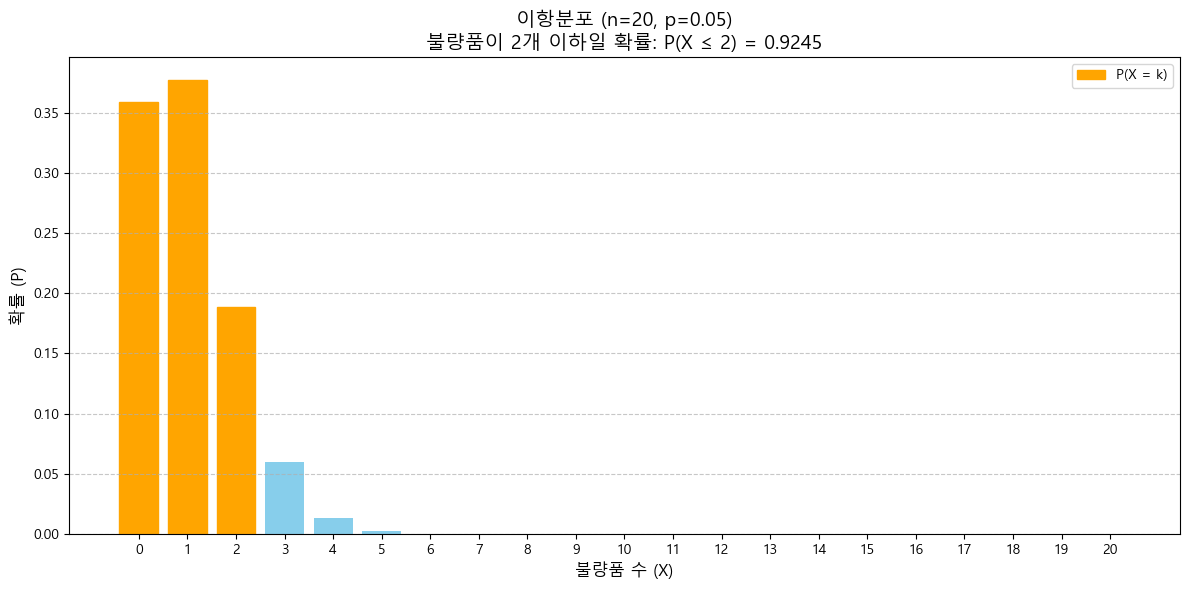

In [39]:
# 2. 불량률 5%, 20개 샘플, 불량제품이 2개 이하일 확률
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
import matplotlib


# 파라미터
n = 20       # 샘플 수
p = 0.05     # 불량률

x = np.arange(0, n + 1)
pmf = binom.pmf(x, n, p)

# 그래프 그리기
plt.figure(figsize=(12, 6))
bars = plt.bar(x, pmf, color='skyblue', label='P(X = k)')

# X ≤ 2 강조
for i in range(0, 3):
    bars[i].set_color('orange')

# 누적 확률 계산
prob = binom.cdf(2, n, p)

# 제목 및 라벨
plt.title(f'이항분포 (n=20, p=0.05)\n불량품이 2개 이하일 확률: P(X ≤ 2) = {prob:.4f}', fontsize=14)
plt.xlabel('불량품 수 (X)', fontsize=12)
plt.ylabel('확률 (P)', fontsize=12)
plt.xticks(np.arange(0, 21, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


# 푸아송 분포

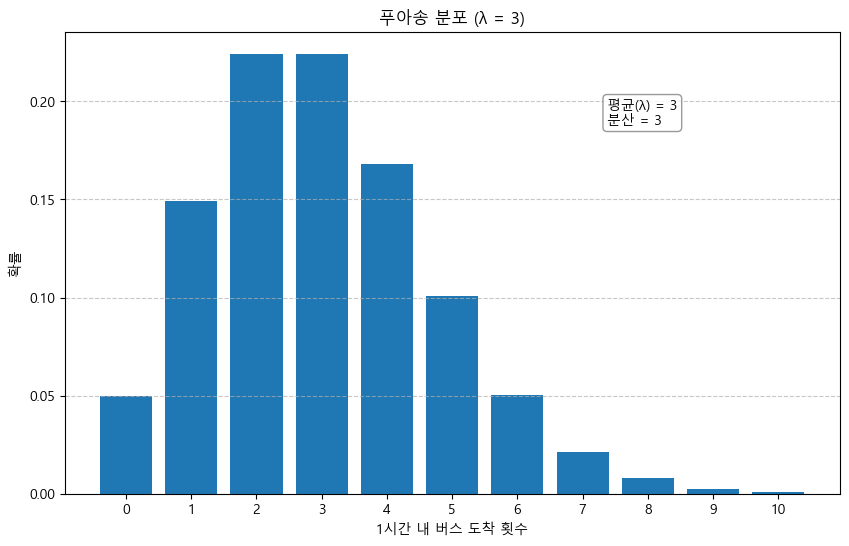

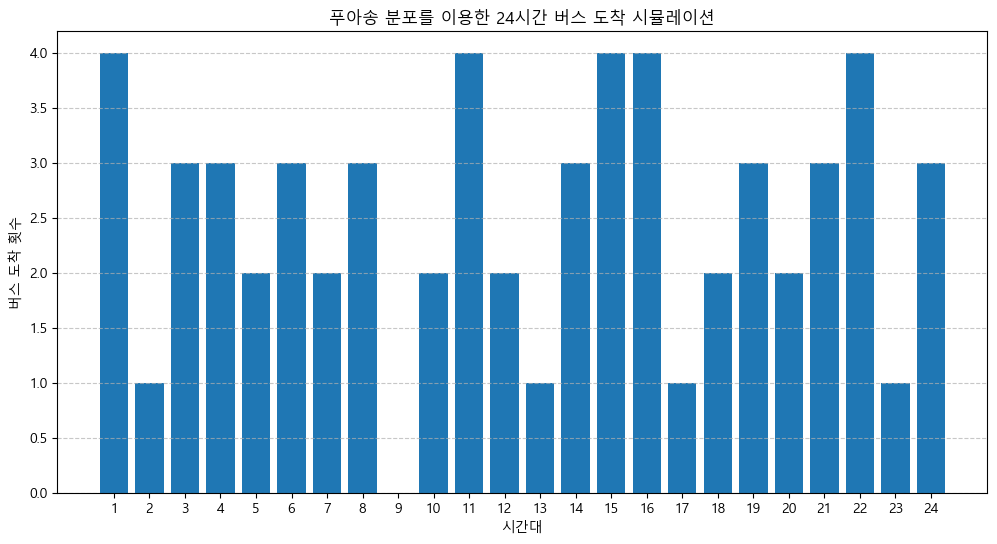

In [35]:
# 1시간 내에 버스가 도착하는 횟수에 대한 확률 분포 계산
# 푸아송 분포 - 버스 도착 시뮬레이션
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 파라미터 설정
lambda_val = 3  # 1시간당 평균 버스 도착 횟수

# 푸아송 확률변수 생성
X = poisson(lambda_val)

# 가능한 버스 도착 횟수 (0부터 10까지)
k_values = np.arange(0, 11)

# 각 값에 대한 확률 계산
pmf_values = X.pmf(k_values)

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.bar(k_values, pmf_values)
plt.xlabel('1시간 내 버스 도착 횟수')
plt.ylabel('확률')
plt.title(f'푸아송 분포 (λ = {lambda_val})')
plt.xticks(k_values)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 평균과 분산 표시
plt.annotate(f'평균(λ) = {lambda_val}\n분산 = {lambda_val}', 
             xy=(0.7, 0.8), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.show()

# 시뮬레이션: 하루(24시간) 동안의 버스 도착 패턴
np.random.seed(42)
hours = np.arange(1, 25)
arrivals = np.random.poisson(lambda_val, size=24)

plt.figure(figsize=(12, 6))
plt.bar(hours, arrivals)
plt.xlabel('시간대')
plt.ylabel('버스 도착 횟수')
plt.title('푸아송 분포를 이용한 24시간 버스 도착 시뮬레이션')
plt.xticks(hours)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 정규 분포

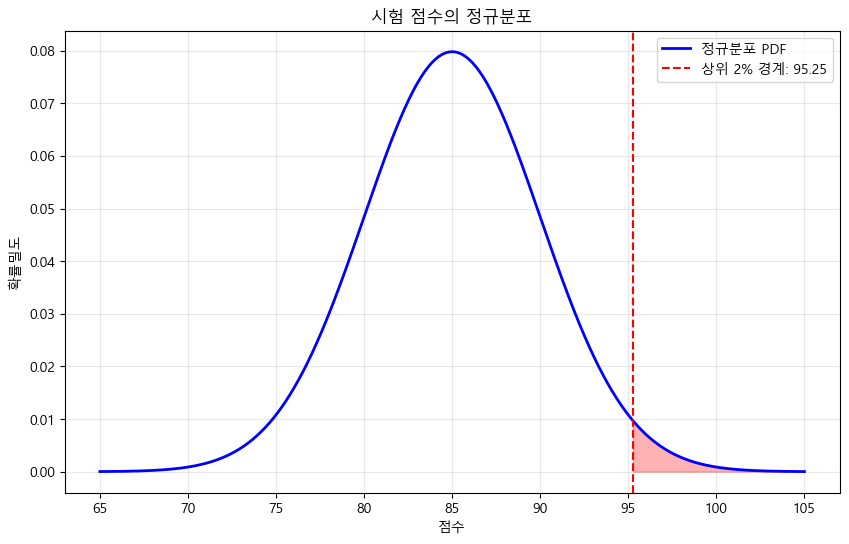

In [36]:
# - 예시) 어느 시험에서 우등반에 들어기가 위해서는 상위 2% 안에 들어야 한다.
# 해당 시험 점수는 정규분포를 따르며, 평균이 85점이고 표준편차가 5일 때, 우등반에 들어기가 위한 최소 시험점수는?  (단 P(Z ≤ 2. 05) = 0. 98)
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 정규분포 예시 코드
mu = 85  # 평균
sigma = 5  # 표준편차

# 정규분포의 확률밀도함수
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf = stats.norm.pdf(x, mu, sigma)

# 상위 2%에 해당하는 점수 계산
z_score = 2.05
critical_value = mu + z_score * sigma

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(x, pdf, 'b-', lw=2, label='정규분포 PDF')
plt.axvline(critical_value, color='r', linestyle='--', label=f'상위 2% 경계: {critical_value:.2f}')
plt.fill_between(x, pdf, where=(x >= critical_value), alpha=0.3, color='r')

# 그래프 꾸미기
plt.title('시험 점수의 정규분포')
plt.xlabel('점수')
plt.ylabel('확률밀도')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# 카이제곱 분포

- 카이제곱 분포에서 적합도/독립성 검정
H0: 범주 간 차이가 없다.
H1: 범주 간 차이가 있다. 샘플링한 그룹에 편향이 있을 수 있다. 적합도가 떨어진다.

- 카이제곱 통계량 -> 관측값과 기대값과의 차이를 수치화

- p-value < 0.05 H0 기각, H1 채택
값이 작을 수록, 관측값이 기대값과 가갑다는 결론

# 확률분포(정리)
### 이산확률분포
- 페르누이: 성골|실패
- 이항분포: 횟수, 성공의 횟수를 모델링
- 포아송분포: 단위(시간/공간) 내에서 사건의 발생횟수를 모델링, 평균 발생율
- 기하분포, 초기하분포, 다항분포
### 연속확률분포
- 정규분포: 평균 중심 - 좌우 대칭, 평균/표준편차
- 표준정규분포: 평균0, 표준편차1인 정규분포 -> Z점수로 확률값을 확인
- 카이제곱분포: X의 제곱합, 분산을 분포로 표시 - 적합도/동질성/분산(변동성), 자유도가 높아질수록 정규분포화
- F분포: 두 분산의 비율을 비교, ANOVA(3개 이상 그룹의 분산 비교)

### 기계학습
분류,회귀 - 방적식/오차 -> 정규분포
시뮬레이션 - X를 추출

